# Phase 4 — Presentation Figures

**Central thesis:** *During breaking-news events, rumours generate faster early engagement than non-rumours, but reach comparable size and structural shape.*

**Six figures, each carrying specific narrative work:**

| # | Figure | Purpose in presentation |
|---|---|---|
| 1 | Hook: rumour vs. non-rumour cascade trees | Open with a concrete visual example |
| 2 | Time-to-first-reply CDFs | The headline finding — rumours engage faster |
| 3 | Per-event consistency bars | Shows the speed finding holds across events |
| 4 | Cascade size box plot | The null finding for reach (supporting evidence) |
| 5 | Depth vs. size scatter | The null finding for shape (supporting evidence) |
| 6 | Pooled vs. stratified comparison | The methodology slide that closes the talk |

**Storyboard logic:**
1. Hook (fig 1) — "Here's what cascades look like."
2. Question — "Do rumours and facts spread differently?"
3. Speed answer (figs 2, 3) — "Yes, on speed: rumours engage faster."
4. Reach + shape answer (figs 4, 5) — "No, on size and structure."
5. Methodology caveat (fig 6) — "Here's how we made sure."

---

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('.').resolve()))
from figures import (
    _setup_style,
    fig1_hook_cascade_trees, fig2_speed_cdfs, fig3_velocity_consistency,
    fig4_reach_null, fig5_structure_null, fig6_methodology_flip,
    fig_per_event_medians_ci,
    fig_verifiability_by_veracity,
    fig_verifiability_speed_quartiles,
    fig_verifiability_violin,
    fig_verifiability_score_vs_speed,
    fig_verifiability_mechanism_summary,
)

_setup_style()

DATA_DIR = Path('../data/processed')
FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

def _load(name):
    pq, pkl = DATA_DIR / f'{name}.parquet', DATA_DIR / f'{name}.pkl'
    return pd.read_parquet(pq) if pq.exists() else pd.read_pickle(pkl)

tm = _load('threads_with_metrics')
edges_df = _load('edges')
threads_df = _load('threads')
consistency = _load('stats_consistency')
medians_with_ci = _load('medians_with_ci')
# Load verifiability-enriched dataset if available (run 05_verifiability first)
_verif_path = DATA_DIR / 'threads_with_verifiability.parquet'
tm_v = pd.read_parquet(_verif_path) if _verif_path.exists() else None

print(f'Loaded {len(tm):,} threads, {len(edges_df):,} edges, {len(consistency)} consistency rows')

Loaded 6,040 threads, 95,076 edges, 55 consistency rows


## Figure 3b — Per-event median ± CI (supplementary)

Same story as Figure 3, but showing the *magnitude* of the speed
difference in every eligible event. Good for a backup slide or the
report appendix.


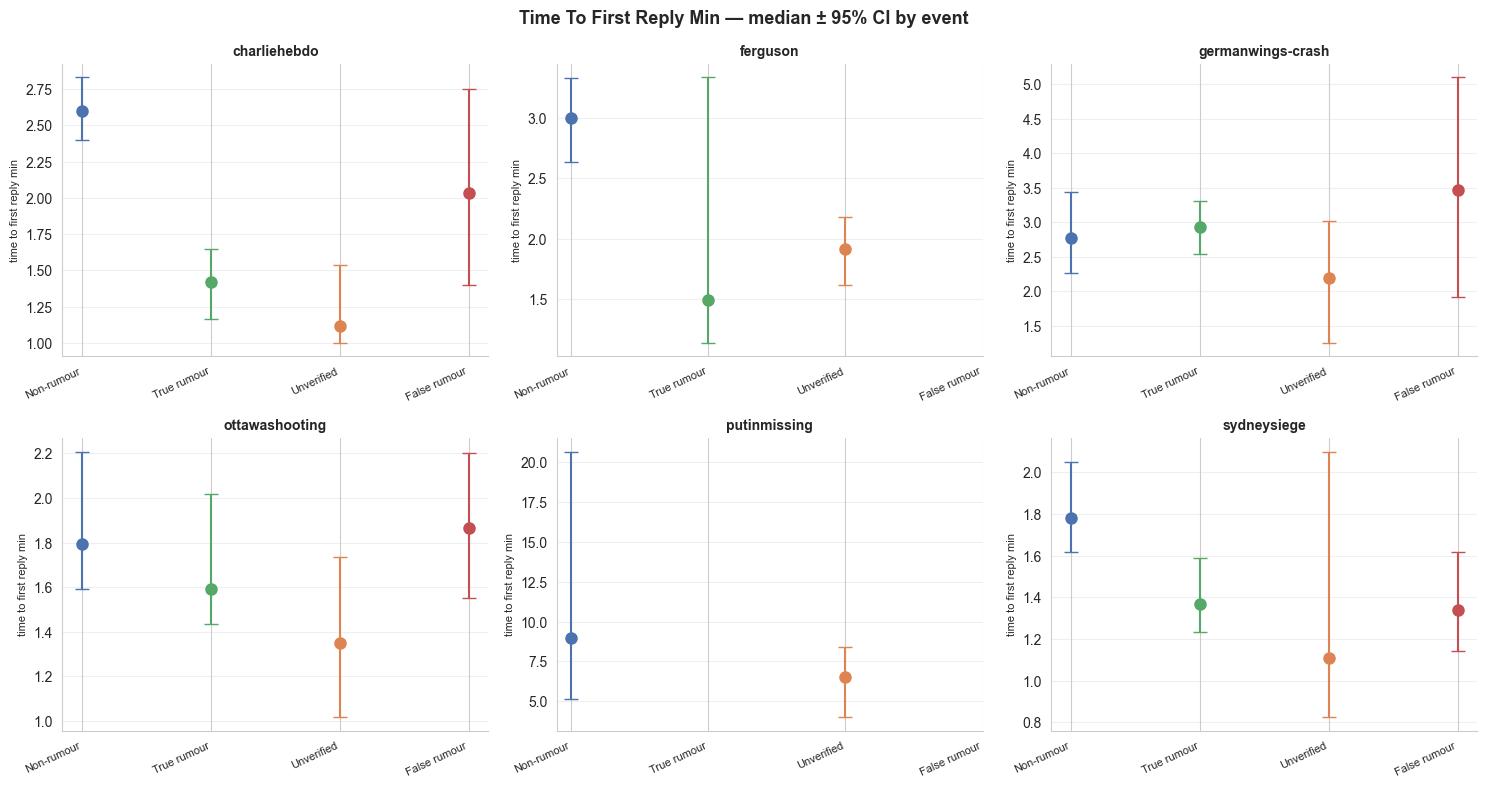

In [2]:
fig3b = fig_per_event_medians_ci(
    medians_with_ci,
    metric='time_to_first_reply_min',
    min_n=10,
    out_path=FIG_DIR / 'fig3b_per_event_speed_ci',
)
plt.show()


## Figure 0 — Class distribution (data slide)

Before any results slide, show the audience what the data looks like.
One stacked bar per event, coloured by veracity. Address the imbalance
head-on: *"Non-rumours dominate every event — this is signal, not a
sampling artefact. Most breaking-news content is genuinely unverified."*


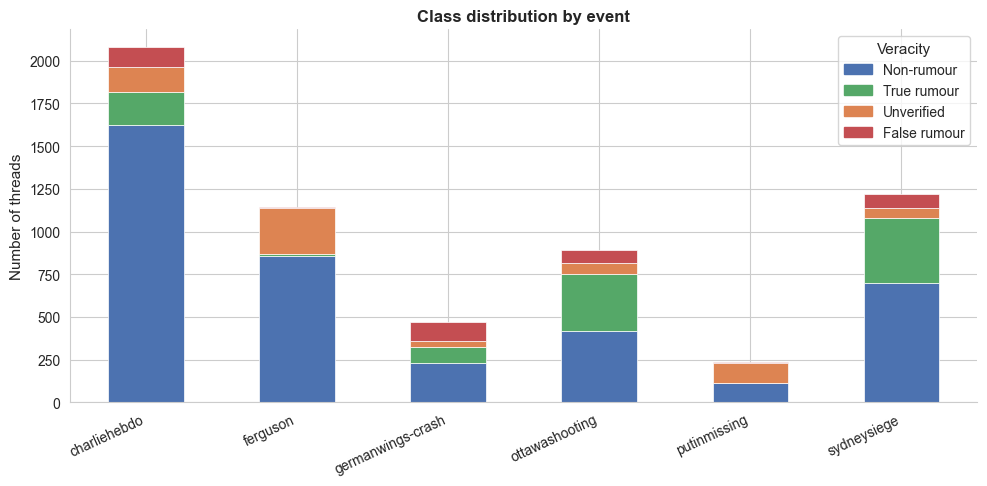

In [3]:
fig0, ax = plt.subplots(figsize=(10, 5))
counts = (
    tm.groupby(['event', 'veracity'])
    .size()
    .unstack('veracity', fill_value=0)
    .reindex(columns=['nonrumour', 'true', 'unverified', 'false'])
)
from figures import VERACITY_COLORS, VERACITY_LABELS, _save
counts.plot(
    kind='bar', stacked=True,
    color=[VERACITY_COLORS[v] for v in ['nonrumour', 'true', 'unverified', 'false']],
    ax=ax, edgecolor='white', linewidth=0.5,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.set_ylabel('Number of threads')
ax.set_xlabel('')
ax.set_title('Class distribution by event', fontweight='bold')
handles = [plt.Rectangle((0,0),1,1, color=VERACITY_COLORS[v]) for v in ['nonrumour','true','unverified','false']]
ax.legend(handles, [VERACITY_LABELS[v] for v in ['nonrumour','true','unverified','false']],
          title='Veracity', loc='upper right')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
_save(fig0, FIG_DIR / 'fig0_class_distribution')
plt.show()


## Figure 1 — The Hook

Pick two visually striking cascades from the same event: one rumour, one non-rumour. Aim for similar sizes if possible — the point of this figure is to *introduce* the audience to what cascades look like, not to make the comparison itself.

**You'll need to manually pick thread IDs.** Run the cell below to find candidates, then edit the `RUMOUR_THREAD_ID` and `NONRUMOUR_THREAD_ID` constants.

In [4]:
# Find good candidate threads: medium-large cascades from charliehebdo
# (the event with the cleanest rumour/nonrumour comparison)
candidates = tm[
    (tm['event'] == 'charliehebdo') &
    (tm['cascade_size'] >= 15) &
    (tm['cascade_size'] <= 50) &
    (tm['structural_virality'].notna())
].sort_values('cascade_size', ascending=False)

print('=== Candidate UNVERIFIED rumours ===')
print(candidates[candidates['veracity'] == 'unverified']
      [['thread_id', 'cascade_size', 'max_depth', 'structural_virality',
        'source_user_screen_name', 'source_text']]
      .head(5).to_string(index=False))
print()
print('=== Candidate NON-RUMOURS ===')
print(candidates[candidates['veracity'] == 'nonrumour']
      [['thread_id', 'cascade_size', 'max_depth', 'structural_virality',
        'source_user_screen_name', 'source_text']]
      .head(5).to_string(index=False))

=== Candidate UNVERIFIED rumours ===
         thread_id  cascade_size  max_depth  structural_virality source_user_screen_name                                                                                                                           source_text
553529196216344576            48         14             8.036348            SkyNewsBreak                                                   Update - AFP reports an armed man has taken a hostage in a kosher grocery in #Paris
553141087725170688            45          8             5.256566             BBCBreaking                      2 brothers suspected of #CharlieHebdo attack spotted in northern France, sources tell AFP http://t.co/spzmOjmyT4
553136845589319680            37         17             7.393393            SkyNewsBreak                  AFP: the two armed suspects who attacked #CharlieHebdo's headquarters yesterday have been located in northern France
552801829290270720            33         12             6.098485       

Rumour thread:     553529196216344576
Non-rumour thread: 553214219899117568


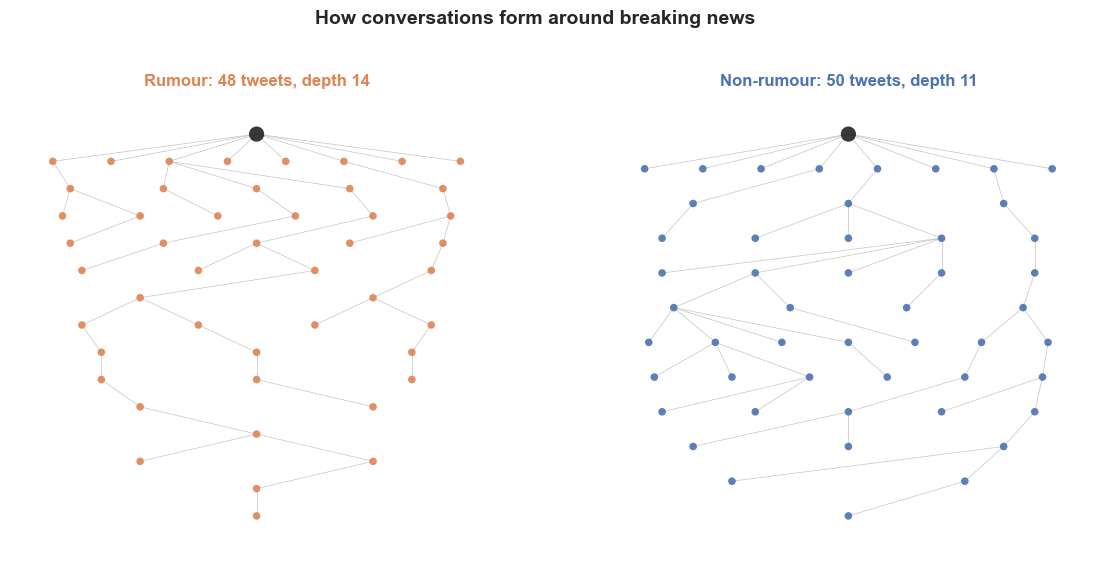

In [5]:
# CHANGE THESE based on what looks visually striking from the candidates above.
# Pick threads of comparable size (within 30%) so the figure is about shape, not magnitude.
RUMOUR_THREAD_ID = candidates[candidates['veracity'] == 'unverified'].iloc[0]['thread_id']
NONRUMOUR_THREAD_ID = candidates[candidates['veracity'] == 'nonrumour'].iloc[0]['thread_id']

print(f'Rumour thread:     {RUMOUR_THREAD_ID}')
print(f'Non-rumour thread: {NONRUMOUR_THREAD_ID}')

fig1 = fig1_hook_cascade_trees(
    edges_df, threads_df,
    rumour_thread_id=RUMOUR_THREAD_ID,
    nonrumour_thread_id=NONRUMOUR_THREAD_ID,
    out_path=FIG_DIR / 'fig1_hook',
)
plt.show()

## Figure 2 — Speed CDFs (the headline finding)

Empirical CDF of time-to-first-reply, one curve per veracity class. The leftmost curve is the fastest. If unverified and true rumours are leftward of non-rumour, the speed thesis is visible at a glance.

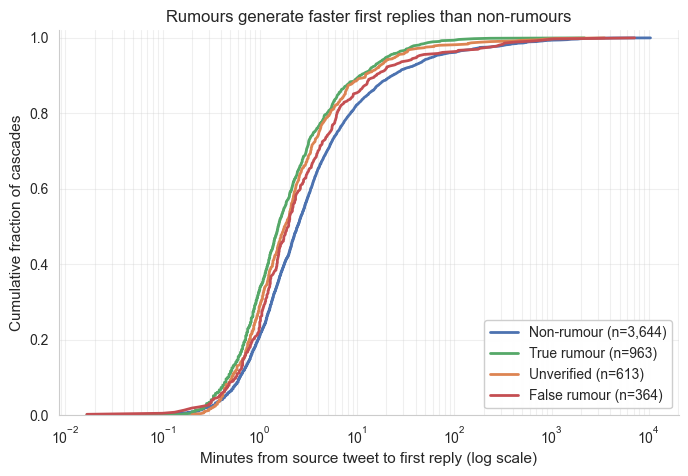

In [6]:
fig2 = fig2_speed_cdfs(
    tm,
    metric='time_to_first_reply_min',
    title='Rumours generate faster first replies than non-rumours',
    xlabel='Minutes from source tweet to first reply (log scale)',
    out_path=FIG_DIR / 'fig2_speed_first_reply',
)
plt.show()

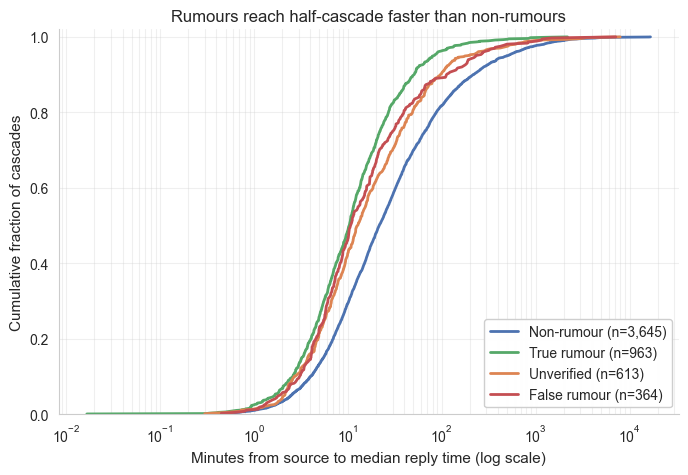

In [7]:
# Bonus: same plot for time_to_half_cascade — the second-strongest speed finding
fig2b = fig2_speed_cdfs(
    tm,
    metric='time_to_half_cascade_min',
    title='Rumours reach half-cascade faster than non-rumours',
    xlabel='Minutes from source to median reply time (log scale)',
    out_path=FIG_DIR / 'fig2b_speed_half_cascade',
)
plt.show()

## Figure 3 — Per-event consistency

For the `unverified vs. nonrumour` comparison: in how many of the eligible events did the pattern hold? This figure proves the speed finding isn't driven by a single event.

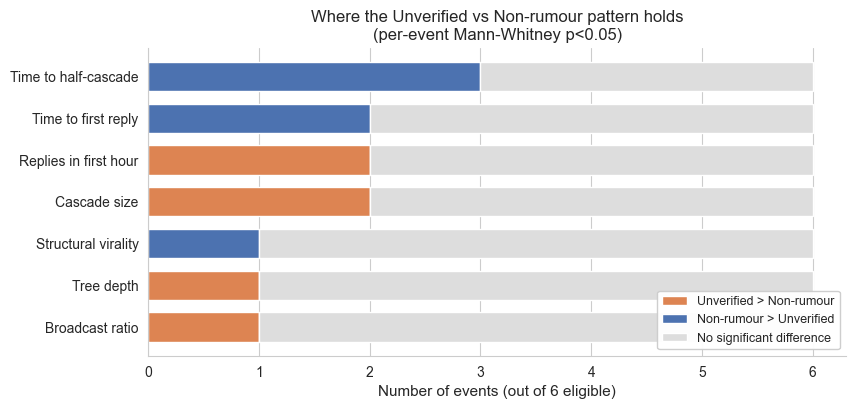

In [8]:
fig3 = fig3_velocity_consistency(
    consistency,
    pair=('unverified', 'nonrumour'),
    out_path=FIG_DIR / 'fig3_consistency_unverified_vs_nonrumour',
)
plt.show()

## Figure 4 — Cascade size is null

The supporting null result: even though rumours engage faster, they don't reach more people overall. Use this on a slide titled something like *"But rumours don't reach more people"* or *"Reach is comparable across veracity"*.

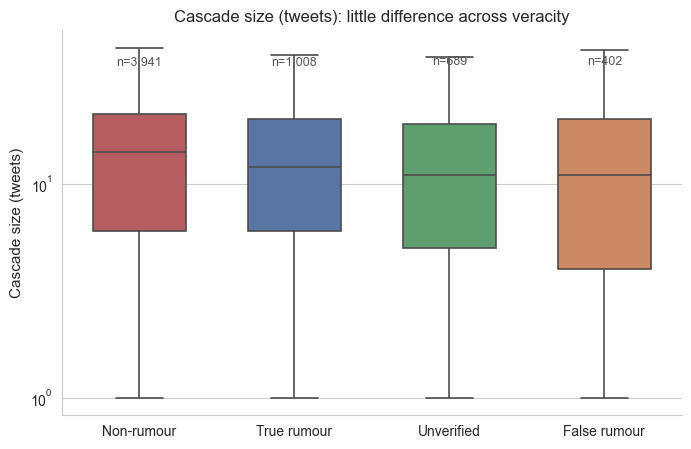

In [9]:
fig4 = fig4_reach_null(
    tm, metric='cascade_size',
    out_path=FIG_DIR / 'fig4_reach_null',
)
plt.show()

## Figure 5 — Cascade shape is null

Scatter of depth vs. size, colored by veracity. If rumours had a distinctive structural signature, the colors would cluster differently. They don't — the second null result.

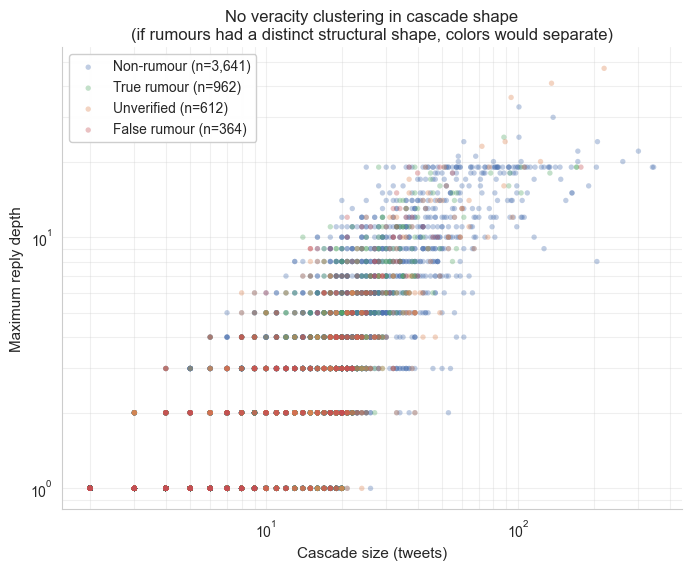

In [10]:
fig5 = fig5_structure_null(
    tm,
    out_path=FIG_DIR / 'fig5_structure_null',
)
plt.show()

## Figure 6 — Pooled vs. stratified (the methodology slide)

Two panels showing how the apparent finding from a naive pooled analysis ("non-rumours are biggest!") gets corrected by per-event stratification (the ranking actually varies by event). This is the closing methodology slide.

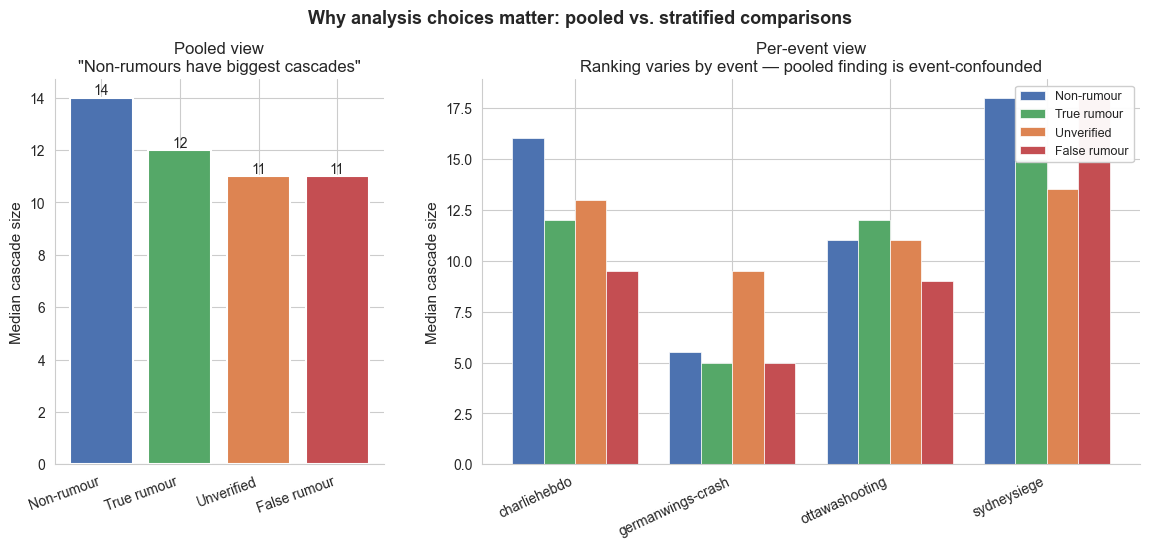

In [11]:
fig6 = fig6_methodology_flip(
    tm,
    metric='cascade_size',
    out_path=FIG_DIR / 'fig6_methodology',
)
plt.show()

## Figures 7 & 8 — Verifiability mechanism

These two slides answer **why** rumours engage faster. A classifier trained
on FEVER (Thorne et al. 2018) scores each PHEME tweet for how 'verifiable'
it is. The punchline: lower verifiability → faster first reply.

> Run `05_verifiability.ipynb` first to generate `threads_with_verifiability.parquet`.

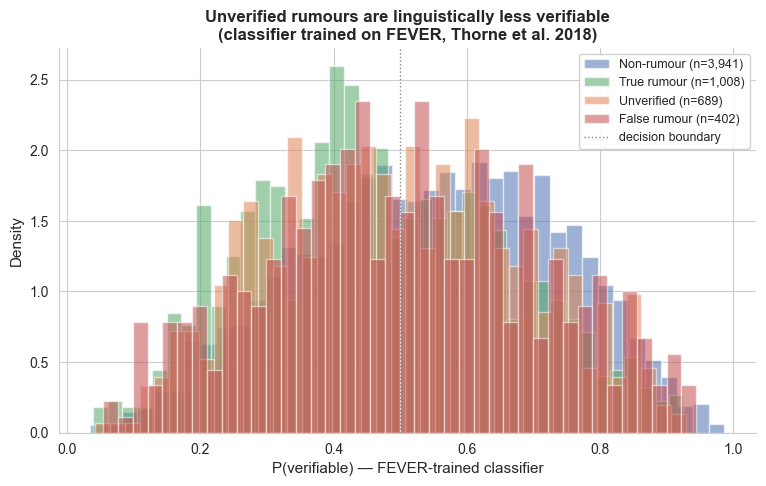

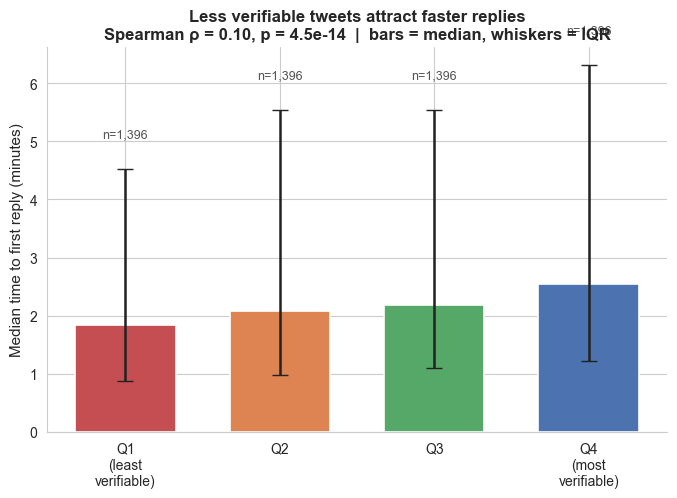

In [12]:
if tm_v is None:
    print('threads_with_verifiability.parquet not found — run 05_verifiability.ipynb first')
else:
    fig7 = fig_verifiability_by_veracity(
        tm_v, out_path=FIG_DIR / 'fig7_verifiability_by_veracity'
    )
    plt.show()

    fig8 = fig_verifiability_speed_quartiles(
        tm_v, out_path=FIG_DIR / 'fig8_verifiability_speed_quartiles'
    )
    plt.show()

## Figures 9–11 — Classifier pipeline highlights

Three additional figures that highlight the FEVER classifier pipeline findings:

| # | Figure | Story |
|---|---|---|
| 9 | Verifiability violin | Full distribution by veracity — true rumours are hardest to verify |
| 10 | Score vs speed scatter | Direct correlation: each point is a cascade, OLS trend shows the relationship |
| 11 | Mechanism summary | 2-panel: veracity → score (left) + score → speed (right) — the one-slide story |


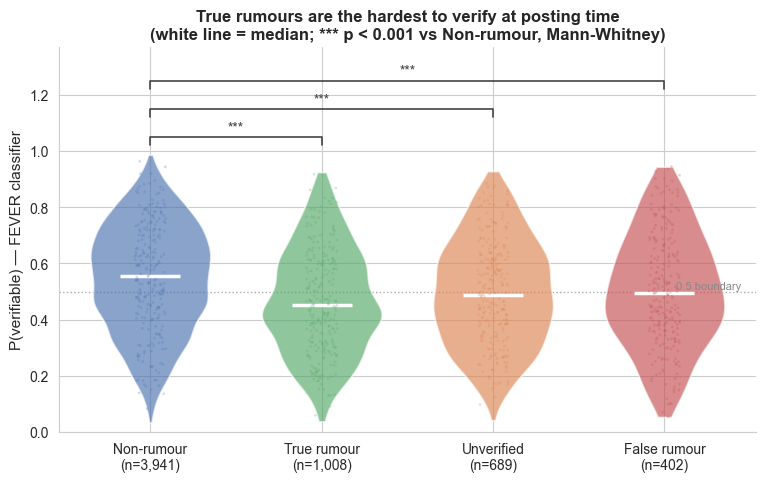

In [13]:
if tm_v is None:
    print('threads_with_verifiability.parquet not found — run 05_verifiability.ipynb first')
else:
    fig9 = fig_verifiability_violin(
        tm_v, out_path=FIG_DIR / 'fig9_verifiability_violin'
    )
    plt.show()

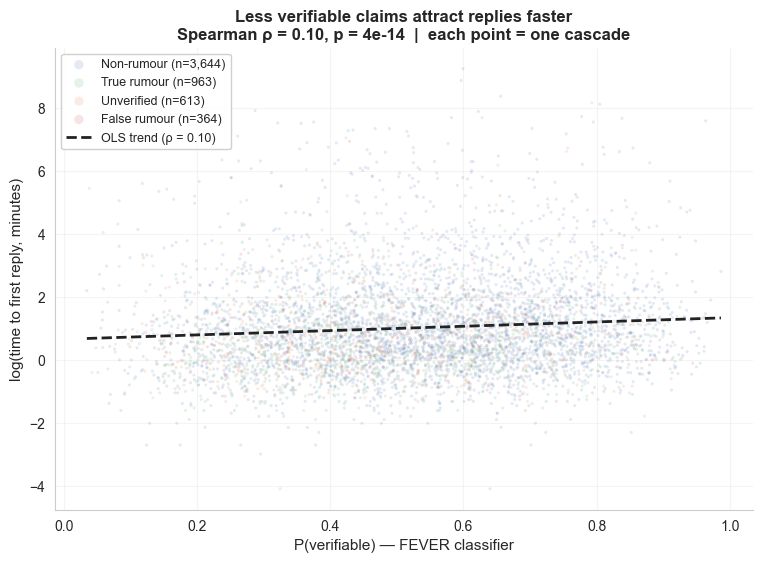

In [14]:
if tm_v is not None:
    fig10 = fig_verifiability_score_vs_speed(
        tm_v, out_path=FIG_DIR / 'fig10_verifiability_score_vs_speed'
    )
    plt.show()

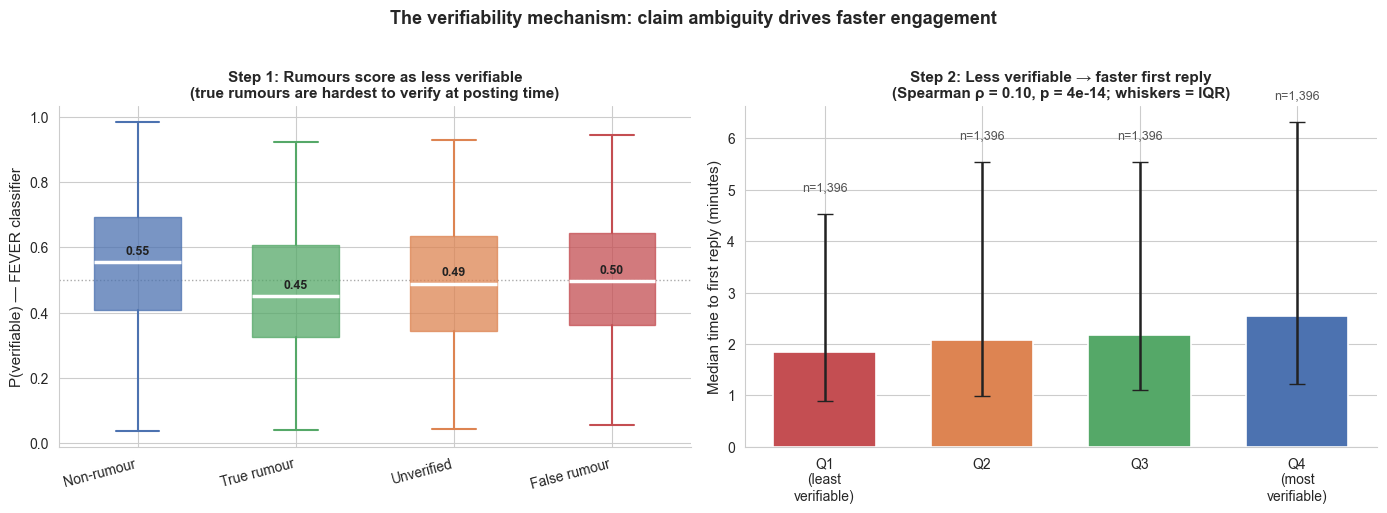

In [15]:
if tm_v is not None:
    fig11 = fig_verifiability_mechanism_summary(
        tm_v, out_path=FIG_DIR / 'fig11_verifiability_mechanism_summary'
    )
    plt.show()

In [ ]:
stats_per_event = _load('stats_per_event')

VERACITY_ORDER  = ['nonrumour', 'true', 'unverified', 'false']
VERACITY_LABELS = {'nonrumour': 'Non-rumour', 'true': 'True rumour',
                   'unverified': 'Unverified', 'false': 'False rumour'}
VERACITY_COLORS_LOCAL = {'nonrumour': '#4C72B0', 'true': '#55A868',
                         'unverified': '#DD8452', 'false': '#C44E52'}

_half = stats_per_event[stats_per_event['metric'] == 'time_to_half_cascade_min']
_tm   = tm[tm['time_to_half_cascade_min'].notna() & (tm['time_to_half_cascade_min'] > 0)]

def _get_delta(event, group_a, group_b):
    row = _half[(_half['event'] == event) & (_half['group_a'] == group_a)
                & (_half['group_b'] == group_b)]
    if len(row) == 0 or not row.iloc[0]['eligible']:
        return None, None
    r = row.iloc[0]
    return r['delta'], '***' if r['significant_bh'] else 'ns'

events_sel = ['charliehebdo', 'sydneysiege', 'ottawashooting', 'germanwings-crash']

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
axes = axes.flatten()

for ax, event in zip(axes, events_sel):
    for v in VERACITY_ORDER:
        vals = _tm.loc[(_tm['event'] == event) & (_tm['veracity'] == v),
                       'time_to_half_cascade_min'].sort_values()
        if len(vals) < 10:
            continue
        cdf = np.arange(1, len(vals) + 1) / len(vals)
        if v == 'nonrumour':
            label = f'Non-rumour  (n={len(vals)})'
        else:
            delta, stars = _get_delta(event, v, 'nonrumour')
            if delta is not None:
                label = f'{VERACITY_LABELS[v]}  (n={len(vals)})   δ={delta:+.2f} {stars}'
            else:
                label = f'{VERACITY_LABELS[v]}  (n={len(vals)})'
        ax.plot(vals.values, cdf, label=label,
                color=VERACITY_COLORS_LOCAL[v], linewidth=2.2)

    ax.set_xscale('log')
    ax.set_title(event, fontsize=13, fontweight='bold')
    ax.set_xlabel('Minutes to median reply (log scale)', fontsize=10)
    ax.set_ylabel('Cumulative fraction', fontsize=10)
    ax.set_xlim(left=0.3)
    ax.set_ylim(0, 1)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(fontsize=9, frameon=True, loc='lower right',
              title="δ = Cliff's δ vs non-rumour", title_fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Time to half-cascade — CDF by veracity, per event',
             fontsize=15, fontweight='bold')
plt.tight_layout()
_save(fig, FIG_DIR / 'time_to_half_cascade_cdf_per_event')
plt.show()

---

## Quick numbers for the speaker notes

These are the headline statistics to memorize and quote during the talk.

In [16]:
stats_pooled = _load('stats_pooled')

print('=== Headline numbers ===\n')

# Speed findings
speed_findings = stats_pooled[
    stats_pooled['metric'].isin([
        'time_to_first_reply_min', 'time_to_half_cascade_min',
        'reply_velocity_first_hour'
    ]) &
    (stats_pooled['n_strata'] >= 3) &
    (stats_pooled['combined_p'] < 0.05)
].sort_values('weighted_delta', key=abs, ascending=False)

print('Speed findings (pooled p<0.05, ≥3 events):')
for _, r in speed_findings.iterrows():
    direction = '<' if r['weighted_delta'] < 0 else '>'
    print(f'  {r["metric"]:30s} {r["group_a"]:10s} {direction} {r["group_b"]:10s} '
          f'  delta={r["weighted_delta"]:+.2f}  p={r["combined_p"]:.0e}')

# Per-event consistency for the headline
print('\nPer-event consistency for unverified vs nonrumour speed:')
speed_cons = consistency[
    (consistency['metric'].isin(['time_to_first_reply_min', 'time_to_half_cascade_min',
                                   'reply_velocity_first_hour'])) &
    (consistency['group_a'] == 'unverified') &
    (consistency['group_b'] == 'nonrumour')
]
print(speed_cons[['metric', 'n_a_greater', 'n_b_greater', 'n_eligible']].to_string(index=False))

# Sample sizes for the methodology slide
print(f'\nDataset: {len(tm):,} threads across {tm["event"].nunique()} events')
print('  By veracity:')
for v in ['nonrumour', 'true', 'unverified', 'false']:
    print(f'    {v:12s} {(tm["veracity"]==v).sum():>5,}')

=== Headline numbers ===

Speed findings (pooled p<0.05, ≥3 events):
  time_to_half_cascade_min       unverified < nonrumour    delta=-0.32  p=8e-03
  time_to_half_cascade_min       true       < nonrumour    delta=-0.30  p=2e-04
  time_to_first_reply_min        unverified < nonrumour    delta=-0.26  p=7e-05
  time_to_first_reply_min        true       < nonrumour    delta=-0.17  p=5e-02
  reply_velocity_first_hour      unverified > nonrumour    delta=+0.17  p=5e-05
  time_to_first_reply_min        false      > unverified   delta=+0.17  p=4e-03

Per-event consistency for unverified vs nonrumour speed:
                   metric  n_a_greater  n_b_greater  n_eligible
reply_velocity_first_hour            2            0           6
  time_to_first_reply_min            0            2           6
 time_to_half_cascade_min            0            3           6

Dataset: 6,040 threads across 6 events
  By veracity:
    nonrumour    3,941
    true         1,008
    unverified     689
    false    

---

## Storyboard for the presentation (15-20 minutes)

**Slide 1 — Title.** *"Spread Dynamics of Rumours vs. Facts"* + your names.

**Slide 2 — The motivating question (Vosoughi 2018).** *"Do falsehoods really travel farther, faster, deeper than truth on Twitter? Vosoughi et al. (Science 2018) said yes. We tested whether this holds during breaking-news events specifically."* (No figure needed, just text.)

**Slide 3 — The data: PHEME-9.** Brief summary: 9 events, ~6,400 threads, ~100k tweets, journalist-annotated for rumour status and (where determinable) veracity. (Maybe a small table of events.)

**Slide 4 — What cascades look like (FIG 1).** Show two cascade trees side-by-side. *"This is what we're studying — reply trees from a source tweet."*

**Slide 5 — Methodology brief.** *"For each thread we computed reach, speed, and structural metrics. We compared veracity classes both pooled and per-event."* (One bullet list.)

**Slide 6 — The speed finding (FIG 2).** *"Rumours generate first replies faster than non-rumours."* Show the CDF. State the effect size: *"Cliff's delta = -0.26 (small-to-medium effect, pooled p<0.001)."*

**Slide 7 — The speed finding holds across events (FIG 3).** *"This isn't driven by one event — the pattern holds in N of M eligible events."* Show consistency bars.

**Slide 8 — But reach is null (FIG 4).** *"Despite engaging faster, rumours don't reach more people overall. Cascade sizes are comparable across veracity classes."*

**Slide 9 — And shape is null (FIG 5).** *"And cascades don't have a distinctive structural signature by veracity. The 'rumours spread more virally' hypothesis doesn't hold here."*

**Slide 10 — Methodology matters (FIG 6).** *"A naive pooled analysis would have suggested non-rumours are biggest. But that finding is event-confounded — it's driven by selection bias in PHEME's source-tweet picks. Per-event stratification corrects this."*

**Slide 11 — Conclusion.** *"Rumours engage faster, not bigger. The speed effect is small but consistent across events. The 'rumours spread differently' intuition is partially correct — but only on the speed dimension."*

**Slide 12 — Limitations.** PHEME is small, English-only, breaking-news-only, journalist-annotated. Reply trees, not full retweet graphs. Snapshot-in-time data.

---

## After running this notebook, you will have in `figures/`:

Each figure saved as both `.png` (for slides) and `.pdf` (for the report). Drop the PNGs straight into PowerPoint or Google Slides at full resolution.
